
# Vietnamese Online News Dataset — Text Preprocessing

**Yêu cầu:** *Preprocess a given text dataset, report the steps and results.*


## 1. Load Dataset



In [1]:

import re
import html
import unicodedata
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 180)

DATA_PATH = "/kaggle/input/datasets/haitranquangofficial/vietnamese-online-news-dataset/news_dataset.json"

df = pd.read_json(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (184539, 10)


,id,author,content,picture_count,processed,source,title,topic,url,crawled_at
0,218270,,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã có thông tin ban đầu về vụ nổ súng,cướp tiệm vàng tại chợ Đông Ba nằm trên đường Trần Hưng Đạo (TP Huế, tỉnh Thừa Thiên - Huế). Thô...",3,0,docbao.vn,"Tên cướp tiệm vàng tại Huế là đại uý công an, công tác tại Trại giam",Pháp luật,https://docbao.vn/phap-luat/ten-cuop-tiem-vang-tai-hue-la-dai-uy-cong-an-cong-tac-tai-trai-giam-tintuc834608,2022-08-01 09:09:22.817308
1,218269,(Nguồn: Sina),"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số, Truyền thông và Truyền thông đại chúng Nga - Oleg Ivanov cho biết trong một cuộc phỏng vấn rằng, đến năm 2025 Viện Khoa học & Côn...",1,0,vtc.vn,"Bỏ qua mạng 5G, Nga tiến thẳng từ 4G lên 6G",Sống kết nối,https://vtc.vn/bo-qua-mang-5g-nga-tien-thang-tu-4g-len-6g-ar691371.html,2022-08-01 09:09:21.181469
2,218268,Hồ Sỹ Anh,"Kết quả thi tốt nghiệp THPT năm 2022 cho thấy điểm trung bình các môn toán, ngoại ngữ giảm, riêng ngữ văn tăng so với năm 2021. Về tổng điểm của 3 môn học năm 2022 là 18,13, gi...",3,0,thanhnien.vn,"Địa phương nào đứng đầu cả nước tổng điểm 3 môn văn, toán, ngoại ngữ?",Giáo dục,https://thanhnien.vn/dia-phuong-nao-dung-dau-ca-nuoc-tong-diem-3-mon-van-toan-ngoai-ngu-post1483653.html,2022-08-01 09:09:15.311901
3,218267,Ngọc Ánh,"Thống đốc Kentucky Andy Beshear hôm 31/7 cho hay sau đợt mưa lũ xối xả vào tuần trước, chính quyền đang nỗ lực làm việc để cung cấp thực phẩm cùng nơi trú ẩn cho hàng nghìn ngư...",1,0,vnexpress,Người chết trong mưa lũ 'nghìn năm có một' ở Mỹ tăng lên 28,Thế giới,https://vnexpress.net/nguoi-chet-trong-mua-lu-nghin-nam-co-mot-o-my-tang-len-28-4494262.html,2022-08-01 09:09:02.211498
4,218266,HẢI YẾN - MINH LÝ,"Vụ tai nạn giao thông liên hoàn trên phố đi bộ Tam Bạc, Hải Phòng vừa xảy ra khiến nhiều người bị thương. Theo những người dân xung quanh khu vực phố đi bộ cho biết, vào khoảng...",12,0,soha,"Hải Phòng: Hình ảnh xe ""điên"" gây tai nạn liên hoàn trên phố đi bộ Tam Bạc",Thời sự - Xã hội,https://soha.vn/hai-phong-hinh-anh-xe-dien-gay-tai-nan-lien-hoan-tren-pho-di-bo-tam-bac-20220801073616434.htm,2022-08-01 09:09:01.601170


## 2. Data Exploration

Kiểm tra các cột dữ liệu, kiểu dữ liệu, giá trị thiếu và số bản ghi trùng lặp trước khi preprocessing.

In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_count"))

duplicate_count = df.duplicated(subset=["content"]).sum()
print("\nDuplicate articles:", duplicate_count)

Columns:
['id', 'author', 'content', 'picture_count', 'processed', 'source', 'title', 'topic', 'url', 'crawled_at']

Data types:


,dtype
id,int64
author,object
content,object
picture_count,int64
processed,int64
source,object
title,object
topic,object
url,object
crawled_at,datetime64[ns]



Missing values:


,missing_count
id,0
author,0
content,0
picture_count,0
processed,0
source,5
title,0
topic,0
url,0
crawled_at,414



Duplicate articles: 27972


## 3. Text Cleaning

Loại bỏ các bản ghi không sử dụng được, sau đó làm sạch các thành phần gây nhiễu trong văn bản.

Các bước cleaning gồm:

- chuẩn hóa Unicode NFC;
- loại bỏ HTML, URL và email;
- chuyển chữ về lowercase;
- loại bỏ dấu câu và ký tự đặc biệt;
- chuẩn hóa khoảng trắng.

Dấu tiếng Việt và chữ số được giữ lại vì vẫn chứa thông tin quan trọng trong văn bản báo chí.

In [3]:
initial_rows = len(df)

# Loại bỏ các bài không có nội dung
before = len(df)
df = df.dropna(subset=["content"]).copy()
df = df[df["content"].astype(str).str.strip() != ""].copy()
removed_missing = before - len(df)

# Loại bỏ bài trùng nội dung
before = len(df)
df = df.drop_duplicates(subset=["content"]).copy()
removed_duplicates = before - len(df)

print("Initial rows:", initial_rows)
print("Removed missing/empty content:", removed_missing)
print("Removed duplicates:", removed_duplicates)
print("Remaining rows:", len(df))

Initial rows: 184539
Removed missing/empty content: 23468
Removed duplicates: 4519
Remaining rows: 156552


In [4]:

def clean_text(text):
    text = str(text)

    # Chuẩn hóa Unicode để biểu diễn ký tự tiếng Việt nhất quán
    text = unicodedata.normalize("NFC", text)

    # Chuyển HTML entity về ký tự thông thường và xóa thẻ HTML
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)

    # Xóa URL và email
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b[\w.\-+]+@[\w.\-]+\.\w+\b", " ", text)

    # Chuyển về chữ thường
    text = text.lower()

    # Xóa dấu câu/ký tự đặc biệt, giữ chữ tiếng Việt và chữ số
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = text.replace("_", " ")

    # Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["content"].apply(clean_text)

display(df[["content", "clean_text"]].head(3))


,content,clean_text
0,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã có thông tin ban đầu về vụ nổ súng,cướp tiệm vàng tại chợ Đông Ba nằm trên đường Trần Hưng Đạo (TP Huế, tỉnh Thừa Thiên - Huế). Thô...",chiều 31 7 công an tỉnh thừa thiên huế đã có thông tin ban đầu về vụ nổ súng cướp tiệm vàng tại chợ đông ba nằm trên đường trần hưng đạo tp huế tỉnh thừa thiên huế thông sài gò...
1,"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số, Truyền thông và Truyền thông đại chúng Nga - Oleg Ivanov cho biết trong một cuộc phỏng vấn rằng, đến năm 2025 Viện Khoa học & Côn...",gần đây thứ trưởng bộ phát triển kỹ thuật số truyền thông và truyền thông đại chúng nga oleg ivanov cho biết trong một cuộc phỏng vấn rằng đến năm 2025 viện khoa học công nghệ ...
2,"Kết quả thi tốt nghiệp THPT năm 2022 cho thấy điểm trung bình các môn toán, ngoại ngữ giảm, riêng ngữ văn tăng so với năm 2021. Về tổng điểm của 3 môn học năm 2022 là 18,13, gi...",kết quả thi tốt nghiệp thpt năm 2022 cho thấy điểm trung bình các môn toán ngoại ngữ giảm riêng ngữ văn tăng so với năm 2021 về tổng điểm của 3 môn học năm 2022 là 18 13 giảm s...


## 4. Tokenization and Stopword Removal

Thực hiện tách từ tiếng Việt bằng `underthesea`, sau đó tạo thêm phiên bản đã loại stopword.

Với tiếng Việt, một từ có thể gồm nhiều âm tiết tách nhau bằng khoảng trắng. Vì vậy dùng tokenizer dành riêng cho tiếng Việt sẽ phù hợp hơn việc chỉ dùng `split()`.

In [5]:
try:
    from underthesea import word_tokenize
except ImportError:
    !pip install -q underthesea
    from underthesea import word_tokenize

df["tokenized_text"] = df["clean_text"].apply(
    lambda x: word_tokenize(x, format="text")
)

display(df[["clean_text", "tokenized_text"]].head(3))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.3 MB/s eta 0:00:00


,clean_text,tokenized_text
0,chiều 31 7 công an tỉnh thừa thiên huế đã có thông tin ban đầu về vụ nổ súng cướp tiệm vàng tại chợ đông ba nằm trên đường trần hưng đạo tp huế tỉnh thừa thiên huế thông sài gò...,chiều 31 7 công_an tỉnh thừa thiên_huế đã có thông_tin ban_đầu về vụ nổ_súng cướp tiệm vàng tại chợ đông ba nằm trên đường trần_hưng_đạo tp huế tỉnh thừa thiên_huế thông_sài gò...
1,gần đây thứ trưởng bộ phát triển kỹ thuật số truyền thông và truyền thông đại chúng nga oleg ivanov cho biết trong một cuộc phỏng vấn rằng đến năm 2025 viện khoa học công nghệ ...,gần đây thứ_trưởng bộ phát_triển kỹ_thuật_số truyền_thông và truyền_thông đại_chúng nga oleg_ivanov cho biết trong một cuộc phỏng_vấn rằng đến năm 2025 viện khoa_học công_nghệ ...
2,kết quả thi tốt nghiệp thpt năm 2022 cho thấy điểm trung bình các môn toán ngoại ngữ giảm riêng ngữ văn tăng so với năm 2021 về tổng điểm của 3 môn học năm 2022 là 18 13 giảm s...,kết_quả thi tốt_nghiệp thpt năm 2022 cho thấy điểm trung_bình các môn_toán ngoại_ngữ giảm riêng_ngữ văn_tăng so với năm 2021 về tổng_điểm của 3 môn_học năm 2022 là 18 13 giảm s...


In [6]:
VIETNAMESE_STOPWORDS = {
    "và", "là", "của", "có", "được", "cho", "trong", "với",
    "một", "những", "các", "đã", "đang", "sẽ", "này", "đó",
    "tại", "từ", "khi", "về", "theo", "trên", "để", "nhưng",
    "không", "cũng", "thì", "như"
}

def remove_stopwords(text):
    return " ".join(
        token for token in text.split()
        if token not in VIETNAMESE_STOPWORDS
    )

df["processed_text"] = df["tokenized_text"].apply(remove_stopwords)

display(df[["tokenized_text", "processed_text"]].head(3))

,tokenized_text,processed_text
0,chiều 31 7 công_an tỉnh thừa thiên_huế đã có thông_tin ban_đầu về vụ nổ_súng cướp tiệm vàng tại chợ đông ba nằm trên đường trần_hưng_đạo tp huế tỉnh thừa thiên_huế thông_sài gò...,chiều 31 7 công_an tỉnh thừa thiên_huế thông_tin ban_đầu vụ nổ_súng cướp tiệm vàng chợ đông ba nằm đường trần_hưng_đạo tp huế tỉnh thừa thiên_huế thông_sài gòn giải_phóng khoản...
1,gần đây thứ_trưởng bộ phát_triển kỹ_thuật_số truyền_thông và truyền_thông đại_chúng nga oleg_ivanov cho biết trong một cuộc phỏng_vấn rằng đến năm 2025 viện khoa_học công_nghệ ...,gần đây thứ_trưởng bộ phát_triển kỹ_thuật_số truyền_thông truyền_thông đại_chúng nga oleg_ivanov biết cuộc phỏng_vấn rằng đến năm 2025 viện khoa_học công_nghệ skolkovo đài_phát...
2,kết_quả thi tốt_nghiệp thpt năm 2022 cho thấy điểm trung_bình các môn_toán ngoại_ngữ giảm riêng_ngữ văn_tăng so với năm 2021 về tổng_điểm của 3 môn_học năm 2022 là 18 13 giảm s...,kết_quả thi tốt_nghiệp thpt năm 2022 thấy điểm trung_bình môn_toán ngoại_ngữ giảm riêng_ngữ văn_tăng so năm 2021 tổng_điểm 3 môn_học năm 2022 18 13 giảm so năm 2021 18 92 điểm ...


## 5. Results

So sánh dữ liệu trước và sau preprocessing bằng số lượng tài liệu, độ dài văn bản và một số ví dụ trực tiếp.

In [7]:
df["word_count_before"] = df["content"].astype(str).str.split().str.len()
df["word_count_after"] = df["processed_text"].str.split().str.len()

final_rows = len(df)
retention_rate = final_rows / initial_rows * 100

summary = pd.DataFrame({
    "Metric": [
        "Initial documents",
        "Missing/empty documents removed",
        "Duplicate documents removed",
        "Final documents",
        "Retention rate (%)",
        "Average words before",
        "Average tokens after"
    ],
    "Value": [
        initial_rows,
        removed_missing,
        removed_duplicates,
        final_rows,
        round(retention_rate, 2),
        round(df["word_count_before"].mean(), 2),
        round(df["word_count_after"].mean(), 2)
    ]
})

display(summary)

,Metric,Value
0,Initial documents,184539.00
1,Missing/empty documents removed,23468.00
2,Duplicate documents removed,4519.00
3,Final documents,156552.00
4,Retention rate (%),84.83
5,Average words before,595.94
6,Average tokens after,365.07


In [8]:
sample_n = min(5, len(df))

display(
    df[["content", "clean_text", "tokenized_text", "processed_text"]]
    .sample(sample_n, random_state=42)
    .reset_index(drop=True)
)

,content,clean_text,tokenized_text,processed_text
0,"Lý giải về nguyên nhân gây mưa vào chiều nay, ông Lê Đình Quyết - phó trưởng phòng dự báo Đài khí tượng thủy văn khu vực Nam Bộ - cho biết do gió mùa Tây Nam hoạt động mạnh lên...",lý giải về nguyên nhân gây mưa vào chiều nay ông lê đình quyết phó trưởng phòng dự báo đài khí tượng thủy văn khu vực nam bộ cho biết do gió mùa tây nam hoạt động mạnh lên về h...,lý_giải về nguyên_nhân gây mưa vào chiều nay ông lê_đình_quyết phó trưởng phòng dự_báo đài khí_tượng thủy_văn khu_vực nam_bộ cho biết do gió_mùa tây_nam hoạt_động mạnh lên về h...,lý_giải nguyên_nhân gây mưa vào chiều nay ông lê_đình_quyết phó trưởng phòng dự_báo đài khí_tượng thủy_văn khu_vực nam_bộ biết do gió_mùa tây_nam hoạt_động mạnh lên hiện_tượng ...
1,"Theo ETNews, “Samsung Display sẽ cung cấp 80 triệu màn hình cho iPhone 14 series.” Báo cáo cho hay, việc sản xuất hàng loạt và giao hàng sẽ bắt đầu vào khoảng quý 3 của năm nay...",theo etnews samsung display sẽ cung cấp 80 triệu màn hình cho iphone 14 series báo cáo cho hay việc sản xuất hàng loạt và giao hàng sẽ bắt đầu vào khoảng quý 3 của năm nay kích...,theo etnews samsung display sẽ cung_cấp 80 triệu màn_hình cho iphone 14 series báo_cáo cho_hay việc sản_xuất hàng_loạt và giao hàng sẽ bắt_đầu vào_khoảng quý 3 của năm nay kích...,etnews samsung display cung_cấp 80 triệu màn_hình iphone 14 series báo_cáo cho_hay việc sản_xuất hàng_loạt giao hàng bắt_đầu vào_khoảng quý 3 năm nay kích_cỡ màn_hình dự_kiến g...
2,Cảnh sát trưởng Copenhagen nói rằng nghi phạm đã sử dụng dịch vụ chăm sóc sức khỏe tâm thần. Các nạn nhân dường như là mục tiêu ngẫu nhiên và không có dấu hiệu cho thấy rõ vụ n...,cảnh sát trưởng copenhagen nói rằng nghi phạm đã sử dụng dịch vụ chăm sóc sức khỏe tâm thần các nạn nhân dường như là mục tiêu ngẫu nhiên và không có dấu hiệu cho thấy rõ vụ nổ...,cảnh_sát trưởng copenhagen nói rằng nghi_phạm đã sử_dụng dịch_vụ chăm_sóc sức khỏe_tâm_thần các nạn_nhân dường_như là mục_tiêu ngẫu_nhiên và không có dấu_hiệu cho thấy rõ vụ nổ...,cảnh_sát trưởng copenhagen nói rằng nghi_phạm sử_dụng dịch_vụ chăm_sóc sức khỏe_tâm_thần nạn_nhân dường_như mục_tiêu ngẫu_nhiên dấu_hiệu thấy rõ vụ nổ_súng hành_động khủng_bố v...
3,"Ngày 30-6, Công an tỉnh Hải Dương cho biết cơ quan Cảnh sát điều tra Công an huyện Thanh Miện vừa ra quyết định khởi tố vụ án gây rối trật tự công cộng xảy ra trên địa bàn xã T...",ngày 30 6 công an tỉnh hải dương cho biết cơ quan cảnh sát điều tra công an huyện thanh miện vừa ra quyết định khởi tố vụ án gây rối trật tự công cộng xảy ra trên địa bàn xã th...,ngày 30 6 công_an tỉnh hải_dương cho biết cơ_quan cảnh_sát điều_tra công_an huyện thanh_miện vừa ra quyết_định khởi_tố vụ án gây_rối trật_tự công_cộng xảy ra trên địa_bàn xã th...,ngày 30 6 công_an tỉnh hải_dương biết cơ_quan cảnh_sát điều_tra công_an huyện thanh_miện vừa ra quyết_định khởi_tố vụ án gây_rối trật_tự công_cộng xảy ra địa_bàn xã thanh_giang...
4,"Dòng tiền thông minh vẫn chảy vào bất động sản Nguồn cung nhỏ giọt trong khi nhu cầu nhà ở vẫn cao giúp cho dự án có quỹ đất lớn, được quy hoạch bài bản thêm phần giá trị. Báo ...",dòng tiền thông minh vẫn chảy vào bất động sản nguồn cung nhỏ giọt trong khi nhu cầu nhà ở vẫn cao giúp cho dự án có quỹ đất lớn được quy hoạch bài bản thêm phần giá trị báo cá...,dòng tiền thông_minh vẫn chảy vào bất_động_sản nguồn cung nhỏ_giọt trong khi nhu_cầu nhà ở vẫn cao giúp cho dự_án có quỹ đất lớn được quy_hoạch bài_bản thêm phần giá_trị báo_cá...,dòng tiền thông_minh vẫn chảy vào bất_động_sản nguồn cung nhỏ_giọt nhu_cầu nhà ở vẫn cao giúp dự_án quỹ đất lớn quy_hoạch bài_bản thêm phần giá_trị báo_cáo mới_đây hãng savills...


### Word Frequency

Kiểm tra nhanh các token xuất hiện nhiều nhất sau preprocessing để đánh giá kết quả cleaning và stopword removal.

,word,frequency
0,người,481439
1,ở,385162
2,đến,377630
3,năm,337911
4,nhiều,331504
5,vào,313101
6,ra,270793
7,ngày,252210
8,sau,242358
9,ông,233084


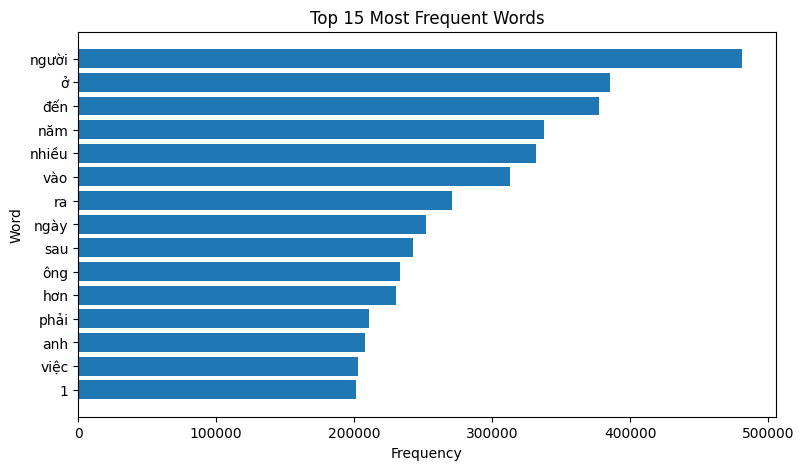

In [9]:
counter = Counter()

for text in df["processed_text"]:
    counter.update(text.split())

top_words = pd.DataFrame(
    counter.most_common(15),
    columns=["word", "frequency"]
)

display(top_words)

plt.figure(figsize=(9, 5))
plt.barh(top_words["word"][::-1], top_words["frequency"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 15 Most Frequent Words")
plt.show()

## 6. Save Processed Dataset



In [10]:
OUTPUT_PATH = "/kaggle/working/vietnamese_news_preprocessed.csv"

df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print("Saved to:", OUTPUT_PATH)
print("Final shape:", df.shape)

Saved to: /kaggle/working/vietnamese_news_preprocessed.csv
Final shape: (156552, 15)



## 7. Conclusion

Dataset đã được tiền xử lý qua các bước chính: loại bỏ dữ liệu thiếu và trùng lặp, làm sạch HTML/URL/email, chuẩn hóa Unicode và chữ thường, tách từ tiếng Việt và loại stopword.

Sau preprocessing, dữ liệu vẫn giữ nguyên dấu tiếng Việt và thông tin số, đồng thời giảm các thành phần gây nhiễu trong văn bản. Kết quả trước và sau được báo cáo bằng số lượng tài liệu, độ dài văn bản trung bình, ví dụ trực tiếp và tần suất từ.
